The idea of this notebook is to try SVR kernel prediction but this time with boiling point feature.

In [11]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # metrics for regression
from sklearn.model_selection import KFold, cross_val_predict, GridSearchCV # cross validation
from sklearn.pipeline import Pipeline # pipeline for model
from sklearn.preprocessing import StandardScaler # standardization
from sklearn.linear_model import Lasso # lasso regression
from sklearn.linear_model import LinearRegression, RANSACRegressor
from sklearn.dummy import DummyRegressor
from sklearn.svm import SVR

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
features_df = pd.read_csv('data/features_df_v1.csv')
features_df.head()

,Unnamed: 0,CID,f1_mass_PC1,f2_lipophilicity_PC1,f3_lipophilicity_extended_PC1,f3_lipophilicity_extended_PC2,f3_lipophilicity_extended_PC3,f3_lipophilicity_extended_PC4,f4_volume_PC1,f5_volume_PC1,...,f12_polarity_PC1,f13_p_vsa_logp_PC1,f13_p_vsa_logp_PC2,f13_p_vsa_logp_PC3,f13_p_vsa_logp_PC4,f13_p_vsa_logp_PC5,f14_spdiam_PC1,f14_spdiam_PC2,f14_spdiam_PC3,f14_spdiam_PC4
0,0,179,-2.286230,-3.199504,-4.752108,0.272682,-1.495469,-0.043973,-2.330895,-2.267296,...,-3.266010,-1.709109,-0.651472,-1.769849,0.042363,-0.585560,-2.207576,-1.116572,-1.030991,0.224150
1,1,240,-1.785254,-0.905835,-2.048200,-0.173442,-0.012213,0.073501,-1.940071,-1.974537,...,1.311706,-2.234276,0.148197,-1.827311,0.561739,-0.324015,-1.478688,-0.873687,-0.965321,-0.331766
2,2,244,-1.729065,-1.110483,-2.498396,-0.262601,-0.143003,0.135432,-1.807131,-1.909753,...,0.110622,-2.565265,-2.724089,-0.667275,0.541062,-0.392053,-1.478688,-0.873687,-0.965321,-0.331766
3,3,323,-0.672035,-0.335579,-1.273646,-0.440255,0.069105,0.099189,-1.355991,-1.277856,...,2.784734,-2.980042,0.105131,0.352292,0.253342,-0.257952,0.145131,-0.468554,-1.085965,-0.530584
4,4,326,-0.614455,0.190988,0.082531,-0.153126,0.156950,0.008979,-0.633067,-0.700927,...,0.835805,-1.540803,0.380345,-1.250471,0.003374,0.332070,-0.104281,-0.199312,-0.716612,-0.227728


In [3]:
bp_feature = pd.read_csv('data/waka_with_imputed_bp.csv')
bp_feature.head()

,Unnamed: 0,CID,bp_value,bp_source
0,0,162268,266.904253,predicted
1,1,2758,176.667000,experimental
2,2,8187,216.603120,predicted
3,3,18827,175.637018,predicted
4,4,17121,193.922596,predicted


In [4]:
# bp added in the last column
features_merged_df = pd.merge(
    features_df,
    bp_feature[['CID', 'bp_value']], on='CID', how='left')
print(features_merged_df.shape)
features_merged_df.head()

(312, 57)


,Unnamed: 0,CID,f1_mass_PC1,f2_lipophilicity_PC1,f3_lipophilicity_extended_PC1,f3_lipophilicity_extended_PC2,f3_lipophilicity_extended_PC3,f3_lipophilicity_extended_PC4,f4_volume_PC1,f5_volume_PC1,...,f13_p_vsa_logp_PC1,f13_p_vsa_logp_PC2,f13_p_vsa_logp_PC3,f13_p_vsa_logp_PC4,f13_p_vsa_logp_PC5,f14_spdiam_PC1,f14_spdiam_PC2,f14_spdiam_PC3,f14_spdiam_PC4,bp_value
0,0,179,-2.286230,-3.199504,-4.752108,0.272682,-1.495469,-0.043973,-2.330895,-2.267296,...,-1.709109,-0.651472,-1.769849,0.042363,-0.585560,-2.207576,-1.116572,-1.030991,0.224150,147.500000
1,1,240,-1.785254,-0.905835,-2.048200,-0.173442,-0.012213,0.073501,-1.940071,-1.974537,...,-2.234276,0.148197,-1.827311,0.561739,-0.324015,-1.478688,-0.873687,-0.965321,-0.331766,178.889000
2,2,244,-1.729065,-1.110483,-2.498396,-0.262601,-0.143003,0.135432,-1.807131,-1.909753,...,-2.565265,-2.724089,-0.667275,0.541062,-0.392053,-1.478688,-0.873687,-0.965321,-0.331766,205.500000
3,3,323,-0.672035,-0.335579,-1.273646,-0.440255,0.069105,0.099189,-1.355991,-1.277856,...,-2.980042,0.105131,0.352292,0.253342,-0.257952,0.145131,-0.468554,-1.085965,-0.530584,299.000000
4,4,326,-0.614455,0.190988,0.082531,-0.153126,0.156950,0.008979,-0.633067,-0.700927,...,-1.540803,0.380345,-1.250471,0.003374,0.332070,-0.104281,-0.199312,-0.716612,-0.227728,153.796459


In [5]:
# I want to standartize pb_value column
features_merged_df['bp_value'] = (features_merged_df['bp_value'] - features_merged_df['bp_value'].mean()) / features_merged_df['bp_value'].std()

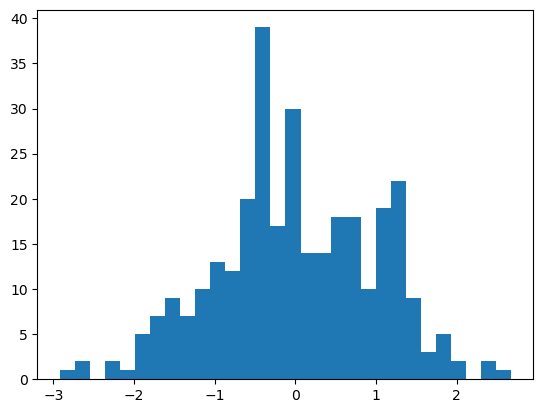

In [7]:
# senity check of standartized bp_value column distribution
plt.hist(features_merged_df['bp_value'], bins=30)
plt.show()

In [9]:
features_merged_df = features_merged_df.loc[:, 'CID':]
features_merged_df.head()

,CID,f1_mass_PC1,f2_lipophilicity_PC1,f3_lipophilicity_extended_PC1,f3_lipophilicity_extended_PC2,f3_lipophilicity_extended_PC3,f3_lipophilicity_extended_PC4,f4_volume_PC1,f5_volume_PC1,f6_volume_PC1,...,f13_p_vsa_logp_PC1,f13_p_vsa_logp_PC2,f13_p_vsa_logp_PC3,f13_p_vsa_logp_PC4,f13_p_vsa_logp_PC5,f14_spdiam_PC1,f14_spdiam_PC2,f14_spdiam_PC3,f14_spdiam_PC4,bp_value
0,179,-2.286230,-3.199504,-4.752108,0.272682,-1.495469,-0.043973,-2.330895,-2.267296,-2.349678,...,-1.709109,-0.651472,-1.769849,0.042363,-0.585560,-2.207576,-1.116572,-1.030991,0.224150,-1.226513
1,240,-1.785254,-0.905835,-2.048200,-0.173442,-0.012213,0.073501,-1.940071,-1.974537,-1.870457,...,-2.234276,0.148197,-1.827311,0.561739,-0.324015,-1.478688,-0.873687,-0.965321,-0.331766,-0.586998
2,244,-1.729065,-1.110483,-2.498396,-0.262601,-0.143003,0.135432,-1.807131,-1.909753,-1.726799,...,-2.565265,-2.724089,-0.667275,0.541062,-0.392053,-1.478688,-0.873687,-0.965321,-0.331766,-0.044829
3,323,-0.672035,-0.335579,-1.273646,-0.440255,0.069105,0.099189,-1.355991,-1.277856,-1.130363,...,-2.980042,0.105131,0.352292,0.253342,-0.257952,0.145131,-0.468554,-1.085965,-0.530584,1.860127
4,326,-0.614455,0.190988,0.082531,-0.153126,0.156950,0.008979,-0.633067,-0.700927,-0.621701,...,-1.540803,0.380345,-1.250471,0.003374,0.332070,-0.104281,-0.199312,-0.716612,-0.227728,-1.098230


In [10]:
features_merged_df.to_csv('data/features_with_pb.csv')

In [ ]:
# now we have 54 + 1 = 55 features
mX = features_merged_df.loc[:, "f1_mass_PC1":].astype(float).values
print(f'mX shape: {mX.shape}')

mX shape: (312, 55)


In [9]:
# Now, lets prepare the target variable
data_df = pd.read_csv('data/waka_dragon_merged.csv')
data_df.head()

,Unnamed: 0.1,Unnamed: 0,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,12,12,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
1,40,40,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
2,42,42,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
3,89,89,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
4,90,90,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0


In [ ]:
# trials to define intensity classes by ref1 (Wakayama)
data_df['Imax_class'] = pd.cut(
    data_df['Imax'].astype(float),
    bins=[0, 1.4, 6.1, 17.2, 35.4, 53.3, np.inf],
    labels=[0, 1, 2, 3, 4, 5],
    right=False,
    include_lowest=True,
).astype(int)

C:\Users\KirilKiriyevsky\AppData\Local\Temp\ipykernel_7184\2211691061.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_df['Imax_class'] = pd.cut(


In [11]:
data_df.head(10)

,Unnamed: 0.1,Unnamed: 0,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,...,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR,Imax_class
0,12,12,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,...,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0,4
1,40,40,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,...,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0,5
2,42,42,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,...,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0,3
3,89,89,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,...,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0,3
4,90,90,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,...,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0,4
5,250,251,454,124-13-0,octanal,78.17,1.33,1.13,1,128.24,...,153.11,0.835,-3.97,-4.21,-4.27,0.0,30.0,0.025,0.0,5
6,182,182,798,120-72-9,indole,43.59,-0.19,0.54,1,117.16,...,100.88,1.022,-2.95,-3.06,-3.06,3.0,46.0,0.000,0.0,4
7,251,252,957,111-87-5,octanol,40.11,0.60,0.51,1,130.26,...,155.75,0.806,-4.10,-4.35,-4.42,0.0,30.0,0.023,0.0,4
8,310,312,1183,121-33-5,vanillin,39.02,-1.81,0.00,1,152.16,...,139.51,0.853,-2.17,-2.20,-2.15,1.0,50.0,0.000,0.0,4
9,43,43,2345,120-51-4,benzyl benzoate,13.25,-2.37,0.16,0,212.26,...,203.34,0.961,-4.38,-4.66,-4.74,2.0,76.0,0.023,0.0,2


In [13]:
imax_class_counts = data_df['Imax_class'].value_counts().sort_index()
print(imax_class_counts)
print(f"\nTotal: {imax_class_counts.sum()}")

Imax_class
1      1
2     24
3    104
4    133
5     50
Name: count, dtype: int64

Total: 312


In [ ]:
vY = data_df['Imax'].astype(float).values

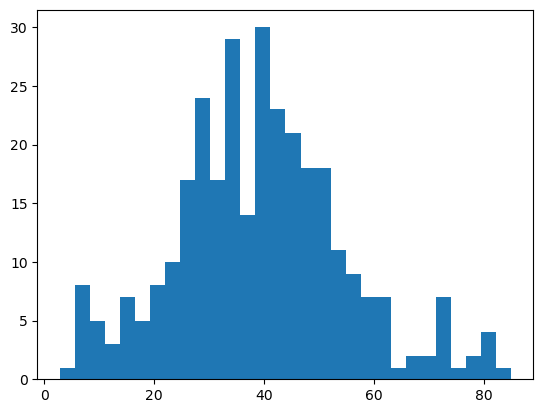

In [27]:
# lets see th Imax destribution
plt.hist(vY, bins=30)
plt.show()


In [31]:
# lets check the base line for prediction with dummy regressor
kf_dummy = KFold(n_splits=len(vY), shuffle=True, random_state=42)
dummy_regressor = DummyRegressor(strategy="mean")
dummy_predictions = cross_val_predict(
    dummy_regressor,
    mX,
    vY,
    cv=kf_dummy,
    n_jobs=-1,
    verbose=4)

dummy_mae = mean_absolute_error(vY, dummy_predictions)
print(f"Dummy MAE: {dummy_mae}")

dummy_r2 = r2_score(vY, dummy_predictions)
print(f"Dummy R2: {dummy_r2}")

Dummy MAE: 12.085438205952675
Dummy R2: -0.0064412071835482365


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 312 out of 312 | elapsed:    0.0s finished


In [32]:
# lets see the linear regression model
linear_regressor = LinearRegression()
linear_predictions = cross_val_predict(
    linear_regressor,
    mX,
    vY,
    cv=kf_dummy,
    n_jobs=-1,
    verbose=4)

linear_mae = mean_absolute_error(vY, linear_predictions)
print(f"Linear MAE: {linear_mae}")

linear_r2 = r2_score(vY, linear_predictions)
print(f"Linear R2: {linear_r2}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    0.1s


Linear MAE: 9.483874324489648
Linear R2: 0.2147199718974403


[Parallel(n_jobs=-1)]: Done 312 out of 312 | elapsed:    0.1s finished


In [33]:
# let try SVR model

svr_regressor = SVR(kernel='rbf')
svr_predictions = cross_val_predict(
    svr_regressor,
    mX,
    vY,
    cv=kf_dummy,
    n_jobs=-1,
    verbose=4)

svr_mae = mean_absolute_error(vY, svr_predictions)
print(f"SVR MAE: {svr_mae}")

svr_r2 = r2_score(vY, svr_predictions)
print(f"SVR R2: {svr_r2}")

SVR MAE: 9.841263564395156
SVR R2: 0.32996342305670845


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done  52 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 265 out of 312 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 312 out of 312 | elapsed:    0.1s finished


In [ ]:
# SVR model with comprehensive grid search

# Same grid spirit as svr_kernel_Imax.ipynb
vC = [0.01, 0.1, 1, 10, 100, 1000]
vEpsilon = [0.01, 0.05, 0.1, 0.5, 1.0]
vGamma = ["scale", "auto", 0.001, 0.01, 0.1, 1]
lParamGrid = [
  {
    "svr__kernel": ["linear"],
    "svr__C": vC,
    "svr__epsilon": vEpsilon,
  },
  {
    "svr__kernel": ["rbf"],
    "svr__C": vC,
    "svr__epsilon": vEpsilon,
    "svr__gamma": vGamma,
  },
  {
    "svr__kernel": ["poly"],
    "svr__C": vC,
    "svr__epsilon": vEpsilon,
    "svr__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    "svr__degree": [2, 3, 4],
    "svr__coef0": [0.0, 0.1, 1.0],
  },
  {
    "svr__kernel": ["sigmoid"],
    "svr__C": vC,
    "svr__epsilon": vEpsilon,
    "svr__gamma": ["scale", "auto", 0.01, 0.1, 1],
    "svr__coef0": [0.0, 0.1, 1.0],
  },
]

pipe_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(max_iter=50_000)),
])

kf_tune = KFold(n_splits=len(vY), shuffle=True, random_state=42)

In [ ]:
oGsSvr = GridSearchCV(
    estimator=pipe_svr,
    param_grid=lParamGrid,
    scoring="neg_mean_absolute_error",
    cv=kf_tune,
    n_jobs=-1,
    refit=True,
    verbose=4,
)
oGsSvr.fit(mX, vY)
print(f"Best CV MAE: {-oGsSvr.best_score_:.2f} ")
print("Best parameters:", oGsSvr.best_params_)

Fitting 100 folds for each of 2010 candidates, totalling 201000 fits
Best CV MAE (100-fold): 8.32 
Best parameters: {'svr__C': 100, 'svr__coef0': 1.0, 'svr__degree': 2, 'svr__epsilon': 0.01, 'svr__gamma': 0.001, 'svr__kernel': 'poly'}


In [37]:
vY_pred = cross_val_predict(oGsSvr.best_estimator_, mX, vY, cv=kf_dummy, n_jobs=-1)

In [38]:
best_mae = mean_absolute_error(vY, vY_pred)
print(f"Best MAE: {best_mae}")
best_r2 = r2_score(vY, vY_pred)
print(f"Best R2: {best_r2}")



Best MAE: 8.309015722998216
Best R2: 0.5026824853152648


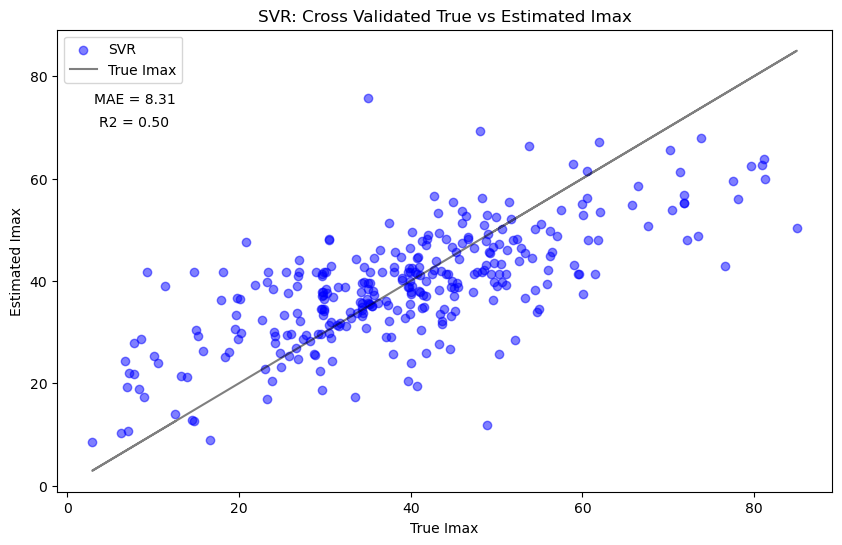

In [43]:
# now let's plot the results
plt.figure(figsize=(10, 6))
plt.scatter(vY, vY_pred, label='SVR', color='blue', alpha=0.5)
plt.plot(vY, vY, label='True Imax', color='black', alpha=0.5)
plt.xlabel('True Imax')
plt.ylabel('Estimated Imax')
plt.title('SVR: Cross Validated True vs Estimated Imax')
plt.text(0.1, 0.85, f'MAE = {best_mae:.2f}', transform=plt.gca().transAxes, ha='center', va='center')
plt.text(0.1, 0.8, f'R2 = {best_r2:.2f}', transform=plt.gca().transAxes, ha='center', va='center')
plt.legend()
plt.show()


In [44]:
# now letr try lasso estimator

param_grid = {
    'lasso__alpha': [0.01, 0.1, 1, 10, 100]
}

pipe_lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(max_iter=50_000))
])

oGsLasso = GridSearchCV(
    estimator=pipe_lasso,
    param_grid=param_grid,  
    scoring="neg_mean_absolute_error",
    cv=kf_tune,
    n_jobs=-1,
    refit=True,
    verbose=4,
)   
oGsLasso.fit(mX, vY)
print(f"Best CV MAE: {-oGsLasso.best_score_:.2f} ")
print("Best parameters:", oGsLasso.best_params_)
vY_pred = cross_val_predict(oGsLasso.best_estimator_, mX, vY, cv=kf_dummy, n_jobs=-1)
best_mae = mean_absolute_error(vY, vY_pred)
print(f"Best MAE: {best_mae}")  



Fitting 100 folds for each of 5 candidates, totalling 500 fits
Best CV MAE: 8.73 
Best parameters: {'lasso__alpha': 0.1}
Best MAE: 8.70754708844795


In [45]:
lasso_ransac_est = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1, max_iter=10_000, random_state=42)),
])

In [48]:
# n ≈ 312: 5-fold is faster than LOOCV for tuning; use LOOCV only for final report
kf_tune = KFold(n_splits=5, shuffle=True, random_state=42)

min_samples_grid = [0.70, 0.75, 0.80, 0.85, 0.90, 0.93, 0.96]  # similar to bp_regression_trail_1

results = []
for ms in min_samples_grid:
    ransac = RANSACRegressor(
        estimator=lasso_ransac_est,
        min_samples=ms,          # fraction of n_samples when float in (0, 1)
        max_trials=100,
        random_state=42,
    )
    y_pred = cross_val_predict(ransac, mX, vY, cv=kf_tune)
    results.append({
        'min_samples': ms,
        'mae': mean_absolute_error(vY, y_pred),
        'r2': r2_score(vY, y_pred),
    })

best_ms = min(results, key=lambda r: r['mae'])['min_samples']
print(best_ms)

0.85


In [50]:
kf_loocv = KFold(n_splits=len(vY), shuffle=True, random_state=42)

ransac_final = RANSACRegressor(
    estimator=lasso_ransac_est,
    min_samples=best_ms,
    max_trials=100,
    random_state=42,
)

vY_pred_ransac = cross_val_predict(ransac_final, mX, vY, cv=kf_loocv)

print('MAE:', mean_absolute_error(vY, vY_pred_ransac))
print('R2: ', r2_score(vY, vY_pred_ransac))

MAE: 8.483256074706585
R2:  0.4858601677201535


In [56]:
vY_class = data_df['Imax_class'].values

In [57]:
pipe = Pipeline([('scaler', StandardScaler()), ('svc', SVC(random_state=42))])
cv = StratifiedKFold(5, shuffle=True, random_state=42)
grid = {
    'svc__C': [0.1, 1, 10, 100, 1000],
    'svc__gamma': ['scale', 0.001, 0.01, 0.1],
    'svc__kernel': ['rbf'],
    'svc__class_weight': [None, 'balanced'],
}

gs = GridSearchCV(pipe, grid, scoring='f1_macro', cv=cv, n_jobs=-1, verbose=2)
gs.fit(mX, vY_class)
print(gs.best_score_, gs.best_params_)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


0.49892859407425283 {'svc__C': 10, 'svc__class_weight': None, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}


In [61]:
y_hat = cross_val_predict(gs.best_estimator_, mX, vY_class, cv=cv)
print(classification_report(vY_class, y_hat))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         1
           2       0.41      0.38      0.39        24
           3       0.59      0.52      0.55       104
           4       0.58      0.68      0.63       133
           5       0.68      0.54      0.60        50

    accuracy                           0.58       312
   macro avg       0.45      0.42      0.43       312
weighted avg       0.58      0.58      0.58       312



c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


In [ ]:
#try huber loss
#  light gbm
# xg boost (learning rate, number of tree)